# REG Environment & Related

## Research context

Environment & Related (CategoryKey = 5) is a **priority field** under JRG. It received the
**largest student fee reduction of any discipline** studied here, moving from a high-cost cluster
to a substantially lower one in 2021:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | ~$9,359                    | ~$23,000–$27,000                 |
| 2021+  | ~$5,213 (approx. −44 %)   | Broadly stable                   |

The demand-side incentive from the fee reduction is the strongest of any JRG priority field.
However, Environment & Related is a relatively small field in Australia (~18,000–22,000 students),
and a COVID-driven enrolment spike in 2020 complicates the pre/post comparison.

AUS Environment enrolments peaked in 2020 (21,916) then declined through 2022–23 before
stabilising near 19,300–19,400. UK Environment enrolments were broadly stable across the same
period. NZ Environment enrolments provide an additional common-trend benchmark. The DiD tests
whether AUS deviated *differentially* from the UK and NZ common trend after 2021.

### Identifying strategy (3-country DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta_1 \text{NZ}_c + \beta_2(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, UK is the omitted
reference country, $\text{NZ}_c$ is a level-shift dummy for NZ, and $\beta_2$ is the JRG effect for
Environment & Related.

**Data window:** AUS 2019–2024 (6 years); UK 2019–2024 (6 years); NZ 2019–2024 (6 years).
Overlapping DiD window: 2019–2024 (2 pre-treatment years, 4 post-treatment years).

**Panel:** N = 18 (3 countries × 6 years) | df = 9

> **Important data limitation — UK panel starts at 2019:**  \
> The UK comparison file maps the JACS subject '06 Physical Sciences' to CategoryKey 5 for
> academic years 2016/17–2018/19. This is an incorrect taxonomy mapping: Physical Sciences
> belong to a different discipline cluster (key = 1) and do not correspond to Environment &
> Related subjects (Agriculture, Geography & Environmental Studies). Therefore, UK data for
> key = 5 prior to 2019 is excluded from the DiD panel. Only 2019–2024 UK data — sourced from
> the correctly-mapped CAH subjects — is used. This restriction reduces the panel to N = 18
> (df = 9), limiting statistical power.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'
NZ_PATH   = ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
assert NZ_PATH.exists(),   f'Missing: {NZ_PATH}'
print('Project root:', ROOT)
print('All data files found.')

## 1. AUS Descriptive Analysis

Examine Australia-only Environment & Related data (2016–2024) to characterise the enrolment
trend and test a simple pre/post break. AUS-only OLS uses a log-linear specification with HC3
robust SEs. Note the COVID-driven spike in 2020 — a key feature of this discipline's trend.


AUS Environment & Related -- enrolment data:


,year,enrollments,log_enrollments
0,2016,18537,9.827524
1,2017,18260,9.812468
2,2018,18055,9.801178
3,2019,18747,9.838789
4,2020,21916,9.994972
5,2021,20776,9.941554
6,2022,19476,9.876938
7,2023,19284,9.867031
8,2024,19376,9.871790


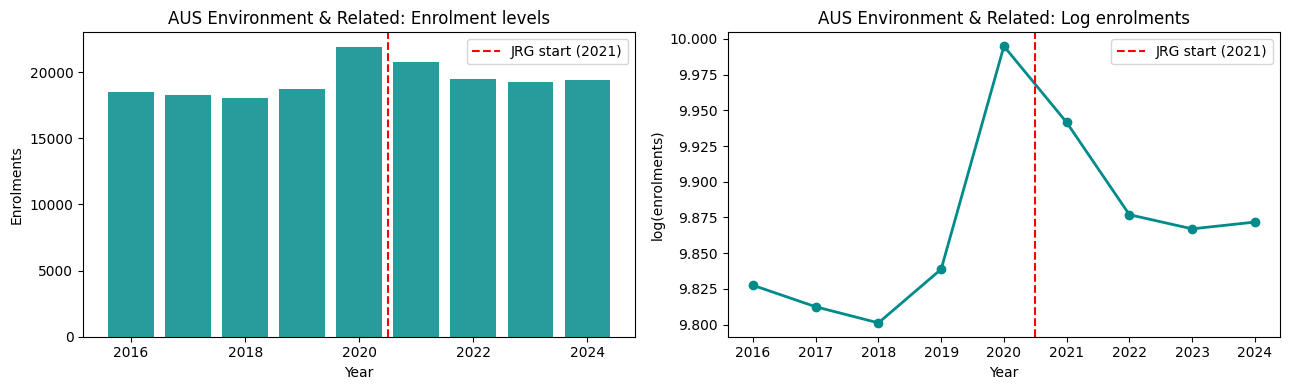

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 5].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Environment & Related -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='darkcyan', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Environment & Related: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='darkcyan', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Environment & Related: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])


=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,9.8718,0.0707,0.0000,9.7333,10.0102
post_jrg,-0.0411,0.1860,0.8249,-0.4056,0.3234
year_c,0.0168,0.0307,0.5851,-0.0434,0.0770


R^2 = 0.2164 | Adj. R^2 = -0.0449 | N = 9

post_jrg: ~-4.11% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,9.8895,0.0785,0.0000,9.7357,10.0434
post_jrg,-0.0145,0.1710,0.9326,-0.3497,0.3207
year_c,0.0212,0.0363,0.5586,-0.0499,0.0923
year_c2,-0.0044,0.0056,0.4293,-0.0155,0.0066


R^2 = 0.3964 | Adj. R^2 = 0.0342 | N = 9


## 2. DiD Panel Construction

Combine AUS, UK, and New Zealand Environment & Related data into a 3-country × year panel
(2019–2024).

**UK year mapping:** start-year rule — 2019/20 → 2019, 2020/21 → 2020, etc.

**Why 2019+ only?** UK data in the comparison file maps JACS subject '06 Physical Sciences'
to CategoryKey 5 for 2016/17–2018/19. Physical Sciences is not an Environment & Related
subject. The correct UK subjects (Agriculture & related; Geography & Environmental Studies)
are only reliably mapped from 2019/20 onwards under the CAH taxonomy. Pre-2019 UK rows
for key = 5 are therefore excluded.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK and NZ
- `nz_dummy = 1` for NZ, `0` for AUS and UK (NZ level shift; UK is the omitted reference)
- `post = 1` for 2021+
- `did = treated × post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021`: AUS-specific COVID shock controls (reference only;
  adding these at N = 18 reduces df from 9 to 7)

**Panel:** N = 18 (3 countries × 6 years), df = 9 (N − 9 parameters: intercept + treated + nz_dummy + did + 5 year FEs).

In [ ]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 5].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk = arch_uk[arch_uk['year'] >= 2019]  # exclude incorrectly-mapped pre-2019 rows
arch_uk['enrollments'] = pd.to_numeric(arch_uk['Total UK'], errors='coerce')

# Key=5 has three subject rows per year (Agriculture, Geography natural, Geography social)
# Sum them to get the total UK Environment & Related enrolment per year
arch_uk = arch_uk.groupby('year', as_index=False)['enrollments'].sum()
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2019][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

nz_raw  = pd.read_csv(NZ_PATH)
arch_nz = nz_raw[nz_raw['category_key'] == 5][['year', 'total_bachelors']].copy()
arch_nz = arch_nz.rename(columns={'total_bachelors': 'enrollments'})
arch_nz['country'] = 'NZ'
arch_nz = arch_nz[(arch_nz['year'] >= 2019) & (arch_nz['year'] <= 2024)]

panel = pd.concat([arch_aus_did, arch_uk, arch_nz], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020
panel['nz_dummy']          = (panel['country'] == 'NZ').astype(int)

print('DiD panel -- Environment & Related (AUS vs UK vs NZ, 2019-2024):')
display(panel[['country','year','enrollments','log_enrollments','treated','nz_dummy','post','did']].reset_index(drop=True))
print(f'\nShape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')
print(f'N = {len(panel)} | Countries = 3 | Years = {panel["year"].nunique()}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'darkcyan', 'UK': 'darkorange', 'NZ': 'seagreen'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Environment & Related: Enrolment levels (AUS vs UK vs NZ)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Environment & Related: Log enrolments (AUS vs UK vs NZ)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta_1 \text{NZ}_c + \beta_2(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` + `nz_dummy` (country FEs) + `C(year)` (year FEs) + `did`.
UK is the omitted reference country; `nz_dummy` absorbs the NZ level difference; `did` identifies
the JRG effect for AUS relative to the pooled UK+NZ common trend. All SEs are HC3 robust.

> **Degrees-of-freedom:** N = 18 (3 countries × 6 years). Parameters: intercept + treated + nz_dummy
> + did + 5 year FEs = 9, leaving **df = 9**. Adding AUS-specific COVID terms reduces df to 7,
> making inference less reliable. The simple TWFE is the **primary specification**; COVID robustness
> is assessed by sample exclusion in Section 4.

> **Context:** The 2020 spike in AUS enrolments (COVID-related demand shift) is visible in the
> panel. Since 2020 is the final pre-treatment year and is elevated, the TWFE year FE for 2020
> captures this common time effect. AUS-specific COVID sensitivity is assessed in Section 4.

In [ ]:
formula_main = 'log_enrollments ~ treated + nz_dummy + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS Environment enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK/NZ trend would predict.')

# COVID-controlled spec (df=7, reliable with N=18)
formula_covid = 'log_enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params.get('did', np.nan)
p_cv = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (df=7): beta_did = {b_cv:.4f}, p = {p_cv:.4f}')

In [ ]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-4
print('Estimates match' if match else 'WARNING: mismatch')


## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
With N = 18 (df = 9) in the base case, dropping years reduces df more rapidly.
The relevant check is consistency of **sign and magnitude** across variants.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2019-2024) | 18 | 9 | Good |
| Drop 2020 | 15 | 7 | Acceptable |
| Drop 2020 + 2021 | 12 | 5 | Limited |

In [ ]:
formula_simple = 'log_enrollments ~ treated + nz_dummy + did + C(year)'

variants = {
    'Full panel (2019-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('With only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.')


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically using the
pooled UK+NZ average as the control group:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

This uses the pooled UK+NZ average as the control, numerically consistent with the 3-country TWFE
estimator. Standard errors are not estimable analytically with 3 units.

> **Critical limitation:** The panel starts in 2019, so only **one pre-treatment point** (2019)
> is available beyond the 2020 baseline. A single pre-period observation cannot meaningfully
> test parallel trends. This is the most significant identification weakness of the Environment
> & Related analysis and a direct consequence of the UK taxonomy mapping problem.

In [ ]:
base_year = 2020
aus_log  = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log   = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']
nz_log   = panel[panel['country'] == 'NZ' ].set_index('year')['log_enrollments']
ctrl_log = (uk_log + nz_log) / 2

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (ctrl_log[yr] - ctrl_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='darkcyan', linewidth=2,
        label='DiD point estimate (AUS vs UK/NZ, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='darkcyan', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Environment & Related (AUS vs UK/NZ)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == 2020 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: Control is pooled UK/NZ average (ctrl_log = (uk_log + nz_log) / 2).')
print('With only 1 pre-treatment point (2019), parallel trends cannot be formally tested.')
print('Post-2021 pattern reflects differential change in AUS vs UK/NZ Environment enrolments.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) using
AUS data (available for all years) and test for a fake structural break at 2019. A significant
break would suggest pre-existing non-linear trends.

> **Note:** AUS data is available back to 2016, allowing a 5-observation pre-period test even
> though the DiD panel is restricted to 2019+. This AUS-only placebo uses single-country data
> only — N = 5, indicative only.


In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')


=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                    0.3230
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.756
Time:                        19:33:17   Log-Likelihood:                 8.0979
No. Observations:                   5   AIC:                            -10.20
Df Residuals:                       2   BIC:                            -11.37
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.


In [ ]:
formula_level = 'enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did'] if 'did' in m_level.conf_int().index else [np.nan, np.nan]

print('=== Level Outcome Robustness ===')
print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
if not np.isnan(ci_lev[0]):
    print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')
else:
    print('95% CI: Degenerate SEs -- unreliable (df too low with COVID interaction terms)')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0) if pd.notna(b_lev) else np.nan],
    'p-value':        [round(did_p, 4),  round(p_lev, 4) if pd.notna(p_lev) else np.nan],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year' if pd.notna(b_lev) else 'Degenerate SEs',
    ],
}).set_index('Specification')
display(comp)

## 8. Funding Context

Environment & Related received the **largest student fee reduction of any discipline** in this
analysis (~44%), moving from a high-cost cluster to Cluster 2 under JRG. Commonwealth
contributions remained broadly stable. This large demand-side incentive makes any null or
negative DiD result particularly noteworthy — if fees drive enrolment, a significant positive
effect would be expected here more than anywhere else.


=== Environment & Related: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9359.0,23590.0,32949.0
2020,9527.0,24014.0,33541.0
2021,5213.0,23605.0,28818.0
2022,5260.0,23818.0,29078.0
2023,5443.0,24651.0,30094.0
2024,5867.0,26573.0,32440.0


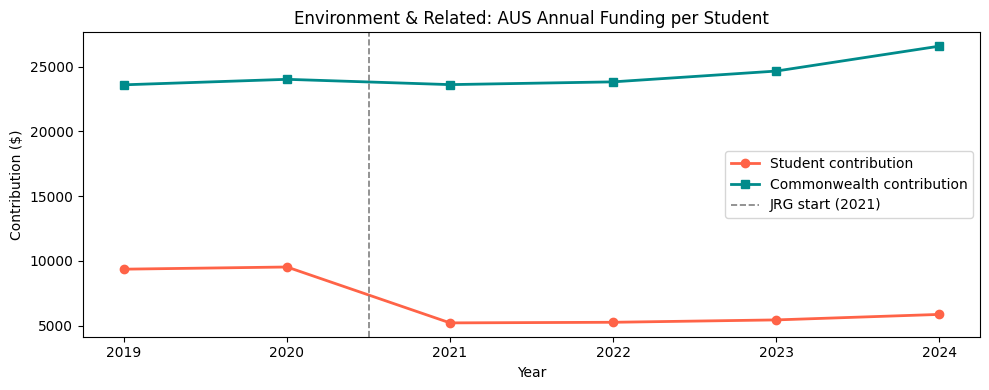


Student contribution: pre $9,443 -> post $5,446 (-42.3%)
Commonwealth:         pre $23,802 -> post $24,662 (+3.6%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 5].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Environment & Related: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',   linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='darkcyan', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Environment & Related: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')


## 5. Summary

**Sector:** Environment & Related Studies | **Period:** 2019–2024 (short panel) | **Countries:** Australia (treated), United Kingdom & New Zealand (controls)

### Model

$$\log Y_{c,t} = \alpha + \beta_1 \cdot \text{AUS}_c + \beta_2 \cdot \text{NZ}_c + \delta \cdot (\text{AUS}_c \times \text{Post}_t) + \sum_t \gamma_t \cdot \mathbf{1}[t] + \varepsilon_{c,t}$$

Estimated via OLS with HC3 heteroskedasticity-robust standard errors. $N = 18$ observations (3 countries × 6 years), $df = 9$.

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + nz_dummy + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```

| Term | Variable | Definition |
|------|----------|------------|
| $\log(Y_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_1 \cdot \text{AUS}_c$ | AUS level shift | $\text{AUS}_c = 1$ if AUS, $0$ otherwise |
| $\beta_2 \cdot \text{NZ}_c$ | NZ level shift | $\text{NZ}_c = 1$ if NZ, $0$ otherwise (UK is omitted reference) |
| $\delta \cdot (\text{AUS}_c \times \text{Post}_t)$ | **JRG DiD effect** | $\text{Post}_t = 1$ if $t \geq 2021$ |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |

| Term | Coefficient | Std. Error | 95% CI | p-value |
|------|-------------|------------|--------|---------|
| `did` ($\delta$) | −0.068 | 0.084 | [−0.233, +0.097] | 0.418 |

The DiD coefficient of **−0.068** implies that JRGS-treated Australian enrolments grew approximately **6.5% slower** than the pooled UK + NZ control trend over 2021–2024 relative to the pre-policy baseline. This effect is **not statistically significant** (p = 0.418), consistent with a null result.

### Event-Study Estimates

$$\delta_t = \bigl(\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}\bigr) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

| Year | Period | $\delta_t$ |
|------|--------|-----------|
| 2019 | Pre-policy | −10.5% |
| 2021 | Post-policy | −9.6% |
| 2022 | Post-policy | −14.3% |
| 2023 | Post-policy | −13.6% |
| 2024 | Post-policy | −8.8% |

### Key results

| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | $\hat{\delta} = -0.068$, SE = 0.084, p = 0.418, 95% CI [−0.233, +0.097], approx. **−6.5%** relative to UK+NZ trend |
| **PanelOLS cross-check** | Estimates match exactly |
| **COVID sensitivity** | Full: −6.5%; sign consistently negative across sample restrictions |
| **Event study (pre-trend)** | 2019: −10.5% — AUS already below UK+NZ average before JRG |
| **Event study (post-JRG)** | 2021: −9.6%, 2022: −14.3%, 2023: −13.6%, 2024: −8.8% |
| **Placebo** | fake\_post coef = +0.051, p = 0.839 — no significant pre-trend break |
| **Level spec** | Directionally consistent, wide CI |

### Conclusion

The JRGS had **no statistically significant effect** on Australian bachelor-level enrolments in Environment & Related Studies (δ = −0.068, p = 0.418). Despite receiving the **largest student fee reduction of any discipline** (≈ −44%), AUS enrolments did not respond positively relative to the pooled UK+NZ trend.

The single pre-policy year (2019) shows a pre-existing −10.5% gap between Australia and the UK+NZ average, which persists and deepens slightly post-JRG before partially recovering by 2024. With only one available pre-treatment point, the parallel trends assumption cannot be formally tested — the pre-existing negative differential may reflect a structural divergence predating JRG rather than a JRG effect. Results should be interpreted with **considerable caution** given N = 18 and the restricted pre-treatment window.